# Practica para flujo de fluidos compresibles

In [ ]:
import numpy as np

#### Explique Brevemente:

1. ¿Por qué motivo el modelo matemático que describe el flujo incompresible es diferente del modelo matemático que describe el flujo compresible a altas velocidades? Mencione con dos razones.

- La densidad del fluido deja de ser constante y pasa a depender significativamente de la presión y la temperatura, por lo que las ecuaciones deben considerar variaciones de densidad a lo largo del flujo.
- A altas velocidades aparecen efectos de compresibilidad asociados al número de Mach, donde la velocidad del fluido puede acercarse a la velocidad del sonido, generando condiciones críticas o choked flow que limitan el flujo másico máximo del sistema.

2. ¿Cuál es el máximo flujo másico al que se puede hacer pasar un fluido compresible dentro de una tubería con un diámetro dado?

- El máximo flujo ocurre cuando el fluido alcanza la condición sónica o crítica dentro de la tubería, es decir, cuando la velocidad del fluido se iguala a la velocidad del sonido en el medio. A partir de este punto ocurre choked flow y disminuir más la presión de salida ya no aumenta el caudal.

#### Considere un flujo de aire en régimen permanente a través de 60 m de una tubería de acero al carbón de 4 in Sch 40 aislada térmicamente desde el tanque de un compresor a una máquina neumática que requiere 20 psi. Previamente se ha calculado que las pérdidas totales, debidas a accesorios equivalen aproximadamente a 6 psi. 

1. ¿Es posible utilizar las ecuaciones de flujo incompresible para hallar la presión requerida en el compresor? Explique.

- No es recomendable usar flujo incompresible, ya que en este caso se trabaja con aire, cuya densidad cambia a medida que avanza el flujo. Además, se presentarán variaciones significativas de presión y, por tanto, también variaciones de velocidad. Debido al aislamiento térmico, el sistema puede aproximarse como un proceso adiabático, por lo que también existirán cambios de temperatura y energía

2. Las especificaciones de la máquina neumática exigen que esta sea alimentada con 50 scfm, ¿Es posible utilizar la tubería existente? Tip. Verifique cual es el flujo máximo de aire que soporta esa tubería en el punto de conexión con la maquina neumática.

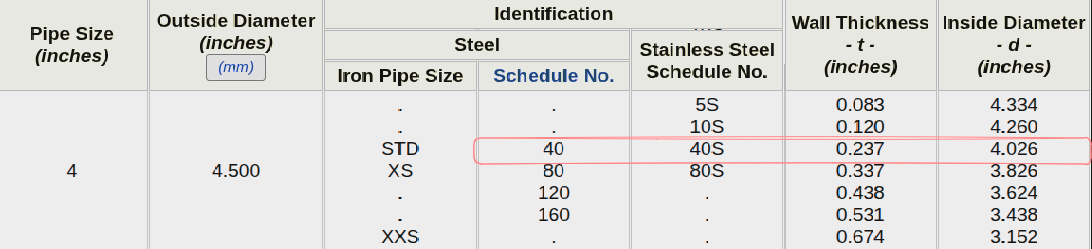

(tomado de : [https://www.engineeringtoolbox.com/steel-pipes-dimensions-d_43.html](https://www.engineeringtoolbox.com/steel-pipes-dimensions-d_43.html))

otras fuentes:
- [https://blog.projectmaterials.com/pipes/pipe-tube-sizes/asme-b36-10-19-pipe-sizes-charts/](https://blog.projectmaterials.com/pipes/pipe-tube-sizes/asme-b36-10-19-pipe-sizes-charts/)
- [https://www.flangeboltchart.com/pipe/schedule/asme-b36-10m](https://www.flangeboltchart.com/pipe/schedule/asme-b36-10m)
- [https://ferrobend.com/dimensions/ansi-asme/pipe/b36.10m/](https://ferrobend.com/dimensions/ansi-asme/pipe/b36.10m/)
- [https://www.atlassteels.com.au/documents/carbon_pipe_dimensions_weights.pdf](https://www.atlassteels.com.au/documents/carbon_pipe_dimensions_weights.pdf)

In [24]:
# Datos
L = 60                                  # m
D = 4.026 / 39.37                       # m
eps = 0.045e-3                          # m

P_atm = 101325                          # Pa
T_std = 15.6 + 273.15                   # K

Q_scfm = 50                             # scfm
Q_std = Q_scfm * (0.3048**3) / 60       # m³/s

R = 287                                 # J/kg·K
mu = 1.8e-5                             # Pa.s

# Area
A = np.pi * D**2 / 4

# Densidad aire estándar
rho = P_atm / (R * T_std)

# Flujo másico
m_dot = rho * Q_std

# Velocidad
V = Q_std / A

# Reynolds
Re = rho * V * D / mu

# Shacham
f = (
    1 / (
        -2 * np.log10(
            (eps / (3.7 * D)) -
            (5.02 / Re) * np.log10(
                (eps / (3.7 * D)) + (14.5 / Re)
            )
        )
    )
) ** 2

# Mach
c = 340
Ma = V / c

print(f"Area                : {A:.6f} m²")
print(f"Densidad            : {rho:.4f} kg/m³")
print(f"Flujo másico        : {m_dot:.5f} kg/s")
print(f"Velocidad           : {V:.4f} m/s")
print(f"Reynolds            : {Re:.2f}")
print(f"Factor fricción     : {f:.6f}")
print(f"Mach                : {Ma:.6f}")

if Ma < 0.3:
    print("\nFlujo muy lejos de choking.")
    print("La tubería soporta el caudal sin problema.")
else:
    print("\nCompresibilidad importante.")

Area                : 0.008213 m²
Densidad            : 1.2227 kg/m³
Flujo másico        : 0.02885 kg/s
Velocidad           : 2.8731 m/s
Reynolds            : 19957.48
Factor fricción     : 0.026880
Mach                : 0.008450

Flujo muy lejos de choking.
La tubería soporta el caudal sin problema.


#### Responda Si o No y justifique en no más de dos líneas:

1. ¿Es posible utilizar un balance de energía mecánica (ecuación de Bernoulli) para calcular las condiciones de flujo de un sistema de aire comprimido? 

- Puede utilizarse como aproximación inicial cuando las velocidades son bajas y la compresibilidad es despreciable. Sin embargo, en flujo compresible la densidad cambia significativamente con la presión y la temperatura, por lo que Bernoulli deja de representar adecuadamente el comportamiento real del sistema. Además, al disminuir la presión el gas puede acelerarse y aproximarse a condiciones sónicas o de flujo de obstrucción (choked flow).

2. ¿Es posible licuificar un gas debido al flujo de este dentro de una tubería?

- Licuificar es realizar cambio de fase de gas-vapor a líquido, y para realizar esta operación es necesario aumentar presión, pero generalmente en un flujo de fluido compresible, no se da el aumento de presión si no hay inyección de trabajo externo, pero si puede darse si disminuye la temperatura. En flujo compresible pueden presentarse disminuciones importantes de temperatura debido a expansión adiabática. Si la temperatura del gas desciende lo suficiente para alcanzar condiciones de saturación, puede ocurrir condensación o licuefacción parcial. Sin embargo, esto depende de las propiedades termodinámicas del gas y de las condiciones de presión y temperatura del sistema.

#### Determine si los siguientes enunciados son Verdaderos o Falsos. Justifique brevemente

1. ¿Es posible generar cambios de fase cuando fluye un gas dentro de una tubería?

- Si, para el caso de flujo no-adiabático donde el gas pierde energía en forma de calor, disminuyendo su temperatura y alcanzando el estado de saturación. Ahora si se presenta altas velocidades de flujo, la energía interna puede convertirse en energía cinética dandose el fenomeno de licuefacción que tambien impulsa la disminución de temperatura

2. ¿Para calcular la velocidad de flujo de un gas es siempre necesario conocer su temperatura?

- No, ya que se puede presentar flujo de un gas isotérmicamente, por lo que ya bastaría con algunas otas variables como cambio de presión del gas, función de densidad, velocidad y areas de flujo, etc

### Calcule el flujo másico máximo de aire que puede pasar por una tubería de DN 1 inch Sch 40 que se usa para alimentar un sistema neumático de control. ¿A cuántos scfm equivalen?

In [25]:
k = 1.4
R = 8.314
T = 298.15
PM = 29 / 1000

D = 1.049 / 39.37
A = np.pi * D**2 / 4

c = np.sqrt(k * R * T / PM)

Q_max_m3s = c * A

rho = (101325 * PM) / (R * T)
m_dot_max = rho * Q_max_m3s
Q_max_scfm = Q_max_m3s * 2118.88

print(f"Velocidad del sonido = {c:.2f} m/s")
print(f"Área = {A:.6e} m²")
print(f"Flujo volumétrico máximo = {Q_max_m3s:.4f} m³/s")
print(f"Flujo másico máximo = {m_dot_max:.4f} kg/s")
print(f"Flujo máximo = {Q_max_scfm:.2f} SCFM")

Velocidad del sonido = 345.93 m/s
Área = 5.575836e-04 m²
Flujo volumétrico máximo = 0.1929 m³/s
Flujo másico máximo = 0.2286 kg/s
Flujo máximo = 408.70 SCFM


### Considere un flujo de aire a régimen permanente a través de 50 m de una tubería de acero al carbón de 2 in Sch 40 aislada térmicamente, desde el tanque de un compresor hasta una maquina neumática. Previamente se ha calculado que las pérdidas totales, debidas a accesorios equivalen aproximadamente a 6 psi.

1. Calcule en scfm el flujo máximo de aire que se puede obtener a la salida de la tubería.
2. Si se requiere aire con una presión de 20 psi a la salida. ¿Es posible utilizar las ecuaciones de flujo incompresible para hallar la presión requerida en el compresor? Explique brevemente.

In [ ]:
k = 1.4
R = 8.314          # J/mol.K
T = 298.15         # K
PM = 29 / 1000     # kg/mol

# Tubería DN 2" Sch 40
D = 2.067 / 39.37  # m
A = np.pi * D**2 / 4 # m²

# Velocidad del sonido
c = np.sqrt(k * R * T / PM)
Q_real_m3s = c * A
Q_real_cfm = Q_real_m3s * 35.3147 * 60

# Condiciones estándar
T_std = 288.15     # K (15°C)
P_std = 14.7       # psia
P_real = 14.7 + 20 # psia

factor = (T / T_std) * (P_std / P_real)
Q_std_scfm = Q_real_cfm / factor

print(f"c               = {c:.2f} m/s")
print(f"Area            = {A:.6f} m²")
print(f"Q_real          = {Q_real_m3s:.4f} m³/s")
print(f"Q_real          = {Q_real_cfm:.2f} cfm")
print(f"Q_std           = {Q_std_scfm:.2f} scfm")


# Parte 2

P_salida_psig = 20
deltaP_psi = 6
P_atm = 14.7

P_compresor_psig = P_salida_psig + deltaP_psi
P_compresor_psia = P_compresor_psig + P_atm
porcentaje_caida = deltaP_psi / P_compresor_psia * 100

print(f"\n\nP_compresor = {P_compresor_psig:.2f} psig")
print(f"P_compresor = {P_compresor_psia:.2f} psia")
print(f"ΔP/P = {porcentaje_caida:.2f} %")

if porcentaje_caida > 10:
    print("No es recomendable usar flujo incompresible.")
    print("Debe utilizarse flujo compresible.")
else:
    print("La aproximación de flujo incompresible es aceptable.")

c               = 345.93 m/s
Area            = 0.002165 m²
Q_real          = 0.7489 m³/s
Q_real          = 1586.84 cfm
Q_std           = 3620.18 scfm


P_compresor = 26.00 psig
P_compresor = 40.70 psia
ΔP/P = 14.74 %
No es recomendable usar flujo incompresible.
Debe utilizarse flujo compresible.


### Considere un flujo de aire en régimen permanente a través de 50 m de una tubería de acero al carbón de 4 in Sch 40 aislada térmicamente desde el tanque de un compresor (punto 1) hasta una maquina neumática ubicada 10 m más alta que el tanque anterior (punto 2).

Seleccione la afirmación verdadera y justifique su respuesta. 

- a. La presión en el punto 2 es mayor que en el punto 1 
- b. El aire recibe calor del ambiente mientras fluye por la tubería 
- c. En un proceso sin fricción (reversible) el aire se calienta mientras fluye del punto 1 al punto 2 
- d. La temperatura del aire en el punto 1 es mayor que en el punto 2

Solucion:

- a. No es verdadero porque el flujo circula desde el compresor hacia la máquina y además existen pérdidas por fricción y aumento de altura. Ambos efectos producen una disminución de presión, por lo que la presión en el punto 2 debe ser menor que en el punto 1.
- b. No es verdadero porque la tubería está aislada térmicamente. Por definición, no existe transferencia de calor entre el aire y el entorno.
- c. No es verdadero porque en un proceso adiabático reversible el aire debe invertir parte de su energía en aumentar su energía potencial al elevarse 10 m. La temperatura no aumenta; por el contrario, tiende a disminuir.
- d. Es verdadero porque el aire asciende 10 m y además experimenta pérdidas por fricción. Como no recibe calor del entorno, la energía disponible disminuye y la temperatura en el punto 2 resulta menor que en el punto 1.


### Considere un ventilador de 50 cm de diámetro que proporciona un aumento de presión de 30 Pa.

- a. ¿Se puede considerar este un flujo a bajas velocidades? Explique por qué.
- b. Calcule el flujo de aire. Tip Asuma que la velocidad del aire en ingreso es despreciable y que no hay pérdidas. La densidad del aire es 1.2 kg/m3.

Solución.

- a. Si, puede considerarse un flujo en baja velocidades, ya que si asumimos que se quiere ventilar aire a presión atmosferica (101325 Pa) e incrementar su presión en 30Pa, seria un aumento de un 0.03%, no sobrepasa el 10%

In [27]:
deltaP = 30      # Pa
rho = 1.2        # kg/m³
D = 0.5          # m

V = np.sqrt((2 * deltaP) / rho)
A = np.pi * D**2 / 4
Q = A * V
m_dot = rho * Q

porcentaje_presion = (deltaP / 101325) * 100

print(f"ΔP/P_atm = {porcentaje_presion:.4f} %")
print(f"V = {V:.4f} m/s")
print(f"A = {A:.4f} m²")
print(f"Q = {Q:.4f} m³/s")
print(f"m_dot = {m_dot:.4f} kg/s")

ΔP/P_atm = 0.0296 %
V = 7.0711 m/s
A = 0.1963 m²
Q = 1.3884 m³/s
m_dot = 1.6661 kg/s


### Se quiere alimentar con gas natural, utilizado como combustible, una caldera pirotubular que genera de vapor. De la ficha técnica de la caldera ésta presenta un consumo máximo de 43 Nm3/h de gas, cuando produce 500 kg/h de vapor a 150 psi. Determine el diámetro de la tubería necesaria para alimentar la caldera a una presión de 30 bar desde un depósito de gas natural a 50 bar y 25 °C. Suponga que el gas natural es metano (CH4), k metano = 1.3. R=8,3144 m2*kg/(s2*K*mol). Asuma régimen permanente, adiabático y sin fricción. 

- a. Calcule la temperatura del gas antes de entrar a la caldera 
- b. Calcule la velocidad del gas antes de entrar a la caldera 
- c. ¿Existirá obstrucción? Verifique calculando el número de Mach 
- d. Calcule el diámetro necesario en la tubería a la entrada de la caldera

In [33]:
P1 = 50e5          # Pa
P2 = 30e5          # Pa
T1 = 25 + 273.15   # K
k = 1.3
R = 8.3144         # J/mol.K
PM = 16.04e-3      # kg/mol

# Condiciones normales (Nm³)
Pn = 101325        # Pa
Tn = 273.15        # K
Qn = 43            # Nm³/h

# --------------------------------------------------
# Flujo másico
# --------------------------------------------------
rho_n = (Pn * PM) / (R * Tn)
Qn_m3s = Qn / 3600
m_dot = rho_n * Qn_m3s

# --------------------------------------------------
# a) Temperatura antes de la caldera
#   Recordar relaciones termodinámicas para procesos
#   Isoentropicos
# --------------------------------------------------
T2 = T1 * (P2 / P1)**((k - 1) / k)

# --------------------------------------------------
# b) Velocidad antes de la caldera
# --------------------------------------------------
rho1 = (P1 * PM) / (R * T1)
V2 = np.sqrt(
    (2 * k / (k - 1))
    * (P1 / rho1)
    * (1 - (P2 / P1)**((k - 1) / k))
)

# --------------------------------------------------
# c) Número de Mach
# --------------------------------------------------
c = np.sqrt(k * R * T2 / PM)
Mach = V2 / c

# --------------------------------------------------
# d) Diámetro requerido
# --------------------------------------------------
rho2 = (P2 * PM) / (R * T2)
A = m_dot / (rho2 * V2)
D = np.sqrt(4 * A / np.pi)

# --------------------------------------------------
# Resultados
# --------------------------------------------------
print(f"Densidad = {rho_n:.4f} kg/m³")
print(f"flujo másico = {m_dot:.6f} kg/s")
print(f"Temperatura antes de entrar a la caldera = {T2:.2f} K ; {T2 - 273.15:.2f} °C")
print(f"Velocidad antes de entrar a la caldera = {V2:.2f} m/s")
print(f"Numero Mach = {Mach:.4f}\n")

if Mach >= 1:
    print("Existe obstrucción (choked flow)")
else:
    print("No existe obstrucción")

print(f"Diametro de flujo = {D:.6f} m ; {D*1000:.2f} mm")

Densidad = 0.7156 kg/m³
flujo másico = 0.008548 kg/s
Temperatura antes de entrar a la caldera = 265.00 K ; -8.15 °C
Velocidad antes de entrar a la caldera = 385.93 m/s
Numero Mach = 0.9133

No existe obstrucción
Diametro de flujo = 0.001136 m ; 1.14 mm
